##AI / Machine Learning (Intelligent Systems)

###Importing Libraries

In [57]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [58]:
#Loading the Dataset
df = pd.read_csv("supplychain_cleaned.csv")
df.head()

,type,days_for_shipping_(real),days_for_shipment_(scheduled),delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_segment,...,shipping_date,shipping_mode,delivery_days,order_month,delay_flag,sales_log,profit_log,order_day,order_week,is_weekend
0,debit,3,4,advance shipping,0,73,sporting goods,caguas,puerto rico,consumer,...,2018-02-03 22:56:00,standard class,3,1,0,5.795298,6.711193,31,5,False
1,transfer,5,4,late delivery,1,73,sporting goods,caguas,puerto rico,consumer,...,2018-01-18 12:27:00,standard class,5,1,1,5.795298,7.057803,13,2,True
2,cash,4,4,shipping on time,0,73,sporting goods,san jose,ee. uu.,consumer,...,2018-01-17 12:06:00,standard class,4,1,0,5.795298,7.056675,13,2,True
3,debit,3,4,advance shipping,0,73,sporting goods,los angeles,ee. uu.,home office,...,2018-01-16 11:45:00,standard class,3,1,0,5.795298,6.791154,13,2,True
4,payment,2,4,advance shipping,0,73,sporting goods,caguas,puerto rico,corporate,...,2018-01-15 11:24:00,standard class,2,1,0,5.795298,6.657485,13,2,True


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180508 entries, 0 to 180507
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   type                           180508 non-null  object 
 1   days_for_shipping_(real)       180508 non-null  int64  
 2   days_for_shipment_(scheduled)  180508 non-null  int64  
 3   delivery_status                180508 non-null  object 
 4   late_delivery_risk             180508 non-null  int64  
 5   category_id                    180508 non-null  int64  
 6   category_name                  180508 non-null  object 
 7   customer_city                  180508 non-null  object 
 8   customer_country               180508 non-null  object 
 9   customer_segment               180508 non-null  object 
 10  customer_state                 180508 non-null  object 
 11  customer_zipcode               180508 non-null  int64  
 12  department_id                 

In [60]:
df.describe()

,days_for_shipping_(real),days_for_shipment_(scheduled),late_delivery_risk,category_id,customer_zipcode,department_id,order_customer_id,order_id,order_item_discount,order_item_discount_rate,...,order_profit_per_order,product_price,product_status,delivery_days,order_month,delay_flag,sales_log,profit_log,order_day,order_week
count,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,...,180508.000000,180508.000000,180508.0,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000,180508.000000
mean,3.497673,2.931837,0.548297,31.849270,35920.246698,5.443454,6690.778857,36219.653999,20.663998,0.101668,...,21.971563,141.222139,0.0,3.471874,6.235197,0.548297,5.119469,6.786418,15.739241,25.505335
std,1.623743,1.374457,0.497663,15.637996,37542.214613,1.629175,4162.304984,21044.057164,21.800753,0.070416,...,104.433860,139.726960,0.0,1.670495,3.403439,0.497663,0.679818,0.105049,8.821841,14.891414
min,0.000000,0.000000,0.000000,2.000000,603.000000,2.000000,1.000000,1.000000,0.000000,0.000000,...,-4274.979980,9.990000,0.0,0.000000,1.000000,0.000000,2.396986,0.000000,1.000000,1.000000
25%,2.000000,2.000000,0.000000,18.000000,725.000000,4.000000,3258.000000,18055.000000,5.400000,0.040000,...,7.000000,50.000000,0.0,2.000000,3.000000,0.000000,4.795625,6.742881,8.000000,13.000000
50%,3.000000,4.000000,1.000000,29.000000,19380.000000,5.000000,6456.000000,36137.500000,14.000000,0.100000,...,31.520000,59.990002,0.0,3.000000,6.000000,1.000000,5.302907,6.781375,16.000000,25.000000
75%,5.000000,4.000000,1.000000,45.000000,78202.500000,7.000000,9779.000000,54141.250000,29.990000,0.160000,...,64.800003,199.990005,0.0,5.000000,9.000000,1.000000,5.706944,6.808819,23.000000,38.000000
max,6.000000,4.000000,1.000000,76.000000,99205.000000,12.000000,20757.000000,77204.000000,500.000000,0.250000,...,911.799988,1999.989990,0.0,6.000000,12.000000,1.000000,7.601397,8.554061,31.000000,53.000000


##1. Advanced ML Models


####Adding new features

In [61]:
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'])
    df['day'] = df['order_date'].dt.day
    df['month'] = df['order_date'].dt.month
    df['weekday'] = df['order_date'].dt.weekday

In [62]:
if 'sales' in df.columns:
    df['lag_1'] = df['sales'].shift(1)
    df['rolling_mean'] = df['sales'].rolling(window=7).mean()

In [63]:
df = df.dropna()

####Selecting only important features

In [64]:
categorical_cols = [
    'shipping_mode',
    'order_status',
    'market',
    'customer_segment',
    'order_region',
    'category_name',
    'department_name'
]


features = [
    'days_for_shipping_(real)',
    'days_for_shipment_(scheduled)',
    'order_item_quantity',
    'delivery_days',
    'order_month',
    'order_day',
    'weekday'
] + categorical_cols

In [65]:
print(df[features + ['sales']].corr(numeric_only=True)['sales'].sort_values(ascending=False))

sales                            1.000000
order_item_quantity              0.106515
order_month                      0.057521
order_day                        0.036335
weekday                          0.007578
days_for_shipment_(scheduled)    0.006282
delivery_days                    0.002727
days_for_shipping_(real)         0.001961
Name: sales, dtype: float64


In [66]:
X = df[features].copy()
y = df['sales']

####Label Encoding for Categorical Columns

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [68]:
X = X.fillna(0)
y = y.fillna(0)

####Model Evaluation

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

####Standard Scaler for Numeric Coluns

In [70]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###1. RANDOM FOREST MODEL

In [71]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

####Prediction

In [72]:
y_pred_rf = rf.predict(X_test)

In [73]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# R2 Score
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

Random Forest Performance:
RMSE: 19.4362662156163
MAE: 3.3908213627908244
R2 Score: 0.9786933852723965


###2. XGBOOST MODEL

In [74]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

####Prediction

In [75]:
y_pred_xgb = xgb.predict(X_test)

In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Prediction
y_pred_xgb = xgb.predict(X_test)

# RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# MAE
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# SAE (Sum of Absolute Errors)
sae_xgb = np.sum(np.abs(y_test - y_pred_xgb))

# R2 Score
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("SAE:", sae_xgb)
print("R2 Score:", r2_xgb)

XGBoost Performance:
RMSE: 18.445562822889915
MAE: 4.2804235296260815
SAE: 154527.56984303117
R2 Score: 0.9808101050377414


##2. CROSS-VALIDATION

In [77]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import r2_score

In [78]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

In [79]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

y_pred_rf_cv = cross_val_predict(rf, X, y, cv=kf, n_jobs=-1)

# SAE
sae_rf = np.sum(np.abs(y - y_pred_rf_cv))

# R2
r2_rf = r2_score(y, y_pred_rf_cv)

print("RF CV SAE:", sae_rf)
print("RF CV R2:", r2_rf)

RF CV SAE: 607927.0280979007
RF CV R2: 0.9780449186209459


In [80]:
xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1)

y_pred_xgb_cv = cross_val_predict(xgb, X, y, cv=kf, n_jobs=-1)

# SAE
sae_xgb = np.sum(np.abs(y - y_pred_xgb_cv))

# R2
r2_xgb = r2_score(y, y_pred_xgb_cv)

print("\nXGB CV SAE:", sae_xgb)
print("XGB CV R2:", r2_xgb)


XGB CV SAE: 1139976.8178746027
XGB CV R2: 0.9684549705517282


### HYPERPARAMETER TUNING

1.Random Forest Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='neg_mean_squared_error')

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)

#### After Tuning → Evaluating Model

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_rf = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Tuned RF R2:", r2)
print("Tuned RF RMSE:", rmse)

2.XGBOOST Tuning

In [ ]:
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='neg_mean_squared_error')

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGB Params:", xgb_grid.best_params_)

####After Tuning - Evaluation Model

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prediction using best model
y_pred_xgb = best_xgb.predict(X_test)

# SAE
sae_xgb = np.sum(np.abs(y_test - y_pred_xgb))

# (Optional but recommended metrics)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("Tuned XGBoost Performance:")
print("SAE:", sae_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2 Score:", r2_xgb)

###Final Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RF
rf_pred = best_rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# XGB
xgb_pred = best_xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("Final RF RMSE:", rf_rmse)
print("Final XGB RMSE:", xgb_rmse)

##3. SHAP EXPLAINABILITY
* Which features increase/decrease predictions
* Most important drivers
* Explain model decisions
* “SHAP values were used to interpret model predictions by quantifying each feature’s contribution.”

In [ ]:
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# 1️⃣ Prepare data
target = 'sales'

# Drop target column for features
X = df.drop(columns=[target])
y = df[target]

# Convert categorical variables using get_dummies
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2️⃣ Train XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# 3️⃣ SHAP Explainer
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

# 4️⃣ Global Feature Importance
shap.plots.bar(shap_values)

# 5️⃣ Beeswarm Plot for feature effect
shap.plots.beeswarm(shap_values)

# 6️⃣ Dependence plot (top feature automatically)
# Get top feature from importance
top_feature = X_test.columns[np.argmax(xgb.feature_importances_)]
shap.dependence_plot(top_feature, shap_values.values, X_test)

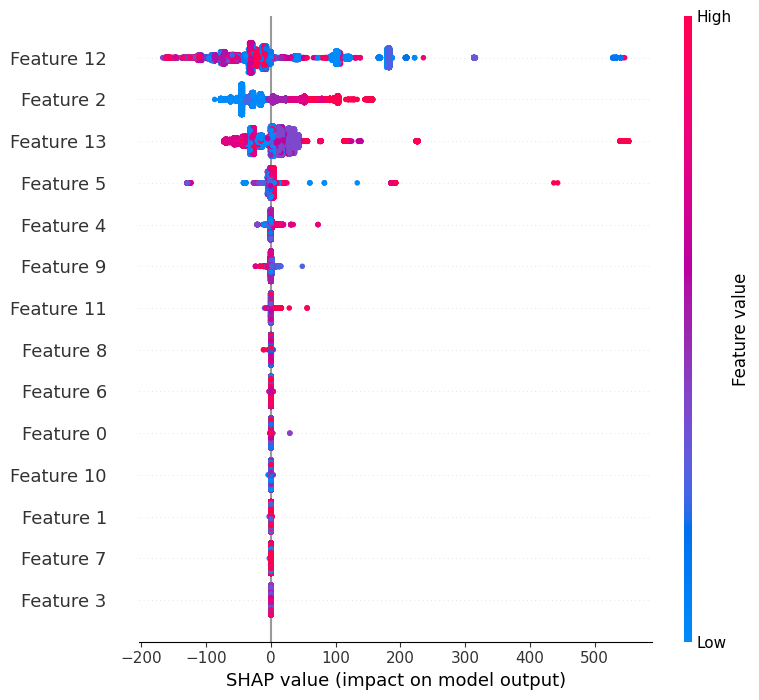

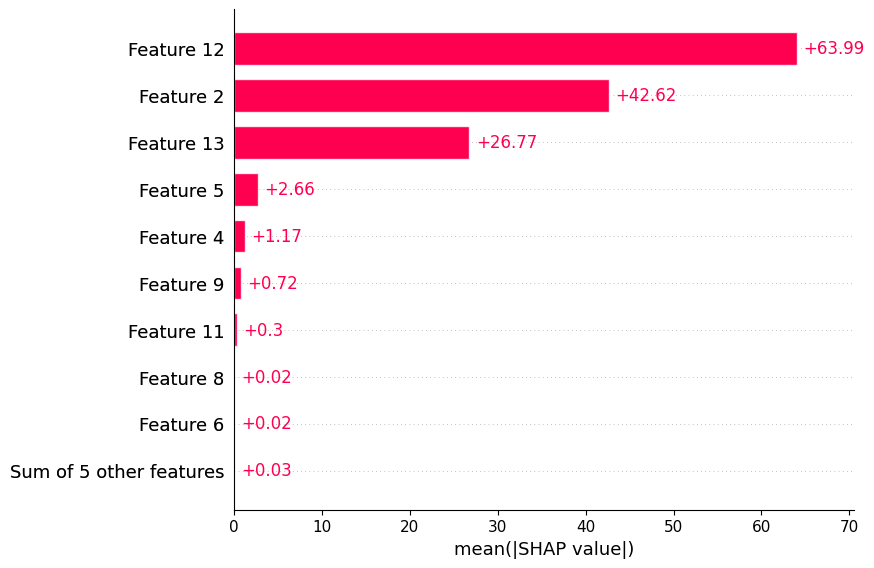

ValueError: Could not find feature named: product_price

In [56]:
# Install if needed
# !pip install shap

import shap

# Create explainer
explainer = shap.Explainer(best_xgb)

# Calculate SHAP values
shap_values = explainer(X_test)

# =========================
# 1. Summary Plot (GLOBAL)
# =========================
shap.summary_plot(shap_values, X_test)

# =========================
# 2. Feature Importance
# =========================
shap.plots.bar(shap_values)

# =========================
# 3. Force Plot (LOCAL)
# =========================
shap.plots.force(shap_values[0])

# =========================
# 4. Dependence Plot
# =========================
shap.dependence_plot("product_price", shap_values.values, X_test)

In [ ]:
df.columns